# Perceptron & Artificial Neuron

## 1. Biological Neuron vs. Artificial Neuron

### Conceptual Overview & Analogy
The human brain contains roughly 86 billion biological neurons connected via intricate networks. Artificial Neural Networks (ANNs) are mathematical approximations inspired by this biological machinery.

| Biological Component | Artificial Counterpart | Function / Description |
| :--- | :--- | :--- |
| **Dendrites** | **Inputs ($x_1, x_2, \dots, x_n$)** | Receive incoming signals (data features) from external environment or prior neurons. |
| **Synapses** | **Weights ($w_1, w_2, \dots, w_n$)** | Determine strength/importance of incoming signals. Synaptic plasticity = Weight updating. |
| **Soma (Cell Body)** | **Weighted Sum ($\sum$) & Bias ($b$)** | Aggregates all incoming signals into a single net electrical potential. |
| **Axon Hillock / Threshold** | **Activation Function ($f$)** | Decides whether the total input voltage exceeds the firing threshold. |
| **Axon & Axon Terminals** | **Output ($y$)** | Transmits the generated output signal to subsequent neurons or motor units. |

### Real-World Example
- **Biological:** Your visual cortex receives light signals (dendrites), evaluates edge sharpness and movement (synapses/weights), aggregates spatial information (soma), and triggers a reaction if a dangerous object is heading toward you (axon output).
- **Artificial:** An automated spam filter takes email word counts ($x$), multiplies them by toxicity/importance weights ($w$), adds a threshold bias ($b$), passes the score through a Step/Sigmoid function, and outputs `1` (Spam) or `0` (Not Spam).

### AI/ML Usage
Understanding this biological inspiration helps in designing deeper architectures (CNNs inspired by visual cortex receptive fields, RNNs inspired by recurrent memory loops).

## 2. Core Architecture of a Perceptron

Introduced by Frank Rosenblatt in 1957, the **Perceptron** is the simplest form of an artificial neural network—a single-layer unit used for binary classification.

### Key Components:
1. **Inputs ($x_i$):** Feature values representing signal inputs.
2. **Weights ($w_i$):** Quantify the influence or strength of each feature on the decision. Positive weights increase activation; negative weights suppress it.
3. **Bias ($b$):** An adjustable threshold offset (equivalent to adding an input $x_0 = 1$ with weight $w_0 = b$). It allows the activation boundary to shift away from the origin.
4. **Weighted Sum ($z$):** Linear combination of inputs, weights, and bias.
5. **Activation Function ($\sigma$ or $f$):** Non-linear (or step) mapping that transforms the linear score $z$ into an actionable output.
6. **Output ($\hat{y}$):** The final prediction (e.g., $0$ or $1$, $-1$ or $+1$).

## 3. Mathematical Representation

For $n$ input features, the linear combination $z$ is computed as:

$$z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = \sum_{i=1}^{n} w_i x_i + b$$

In vectorized linear algebra notation:

$$z = \mathbf{w}^T \mathbf{x} + b$$

Where:
- $\mathbf{w} = [w_1, w_2, \dots, w_n]^T$ is the weight vector.
- $\mathbf{x} = [x_1, x_2, \dots, x_n]^T$ is the input feature vector.

The final predicted output is derived by passing $z$ through an activation function:

$$\hat{y} = 	ext{activation}(z)$$

For Rosenblatt's classic Perceptron, the activation function is the **Heaviside Step Function**:

$$	ext{Step}(z) = \begin{cases} 1 & \text{if } z \ge 0 \\ 0 & \text{if } z < 0 \end{cases}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def step_function(z):
    """Heaviside step activation function."""
    return np.where(z >= 0, 1, 0)

def artificial_neuron(X, weights, bias):
    """
    Computes output of a simple artificial neuron.
    X: input matrix of shape (m_samples, n_features)
    weights: weight array of shape (n_features,)
    bias: scalar threshold value
    """
    
    z = np.dot(X, weights) + bias
    
    output = step_function(z)
    return z, output


sample_x = np.array([2.5, 1.5])  # Feature vector
sample_w = np.array([0.8, -0.5]) # Weights
sample_b = -1.0                  # Bias

z_val, y_val = artificial_neuron(sample_x, sample_w, sample_b)
print(f"Inputs: {sample_x}")
print(f"Weights: {sample_w}, Bias: {sample_b}")
print(f"Calculated Weighted Sum (z): {z_val:.2f}")
print(f"Neuron Output (Step Activation): {y_val}")

Inputs: [2.5 1.5]
Weights: [ 0.8 -0.5], Bias: -1.0
Calculated Weighted Sum (z): 0.25
Neuron Output (Step Activation): 1


## 4. Building Logic Gates with a Perceptron

We can model basic Boolean logic operations using a simple neuron by hand-crafting the weights and bias values.

In [2]:

X_gate = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])


w_and = np.array([1.0, 1.0])
b_and = -1.5  # Requires z = 1(1) + 1(1) - 1.5 = 0.5 >= 0

_, y_and = artificial_neuron(X_gate, w_and, b_and)


w_or = np.array([1.0, 1.0])
b_or = -0.5   # Requires z = 1(0) + 1(1) - 0.5 = 0.5 >= 0

_, y_or = artificial_neuron(X_gate, w_or, b_or)


print("================ AND GATE OUTPUT ================")
for i in range(len(X_gate)):
    print(f"Input: {X_gate[i]} --> Output: {y_and[i]}")

print("\n================ OR GATE OUTPUT ================")
for i in range(len(X_gate)):
    print(f"Input: {X_gate[i]} --> Output: {y_or[i]}")

================ AND GATE OUTPUT ================
Input: [0 0] --> Output: 0
Input: [0 1] --> Output: 0
Input: [1 0] --> Output: 0
Input: [1 1] --> Output: 1

================ OR GATE OUTPUT ================
Input: [0 0] --> Output: 0
Input: [0 1] --> Output: 1
Input: [1 0] --> Output: 1
Input: [1 1] --> Output: 1


## 5. Perceptron Learning Algorithm

Instead of manually picking weights and bias, the perceptron learns them automatically from data using the **Perceptron Update Rule**:

$$w_i := w_i + lpha (y - \hat{y}) x_i$$
$$b := b + lpha (y - \hat{y})$$

where $lpha$ is the learning rate, $y$ is the ground truth, and $\hat{y}$ is the current predicted output.

In [3]:

class Perceptron:
    def __init__(self, learning_rate=0.1, epochs=20):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.errors_history = []
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        
        for epoch in range(self.epochs):
            total_error = 0
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_pred = step_function(linear_output)
                
                # Compute error
                error = y[idx] - y_pred
                total_error += abs(error)
                
                # Update weights and bias
                update = self.lr * error
                self.weights += update * x_i
                self.bias += update
                
            self.errors_history.append(total_error)
            if total_error == 0:
                print(f"[+] Converged successfully at Epoch {epoch + 1}!")
                break
                
    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return step_function(linear_output)

# Verify Perceptron Learning on AND gate
y_and_truth = np.array([0, 0, 0, 1])
p_and = Perceptron(learning_rate=0.1, epochs=10)
p_and.fit(X_gate, y_and_truth)
print(f"Learned Weights: {p_and.weights}, Learned Bias: {p_and.bias:.2f}")
print(f"Predictions: {p_and.predict(X_gate)}")

[+] Converged successfully at Epoch 4!
Learned Weights: [0.2 0.1], Learned Bias: -0.20
Predictions: [0 0 0 1]


## 6. The Limitation of a Single Perceptron: The XOR Problem

### Why a Single Perceptron Fails on XOR
A single-layer perceptron constructs a linear decision boundary: $w_1 x_1 + w_2 x_2 + b = 0$, which represents a **straight line** in 2D space.

- **Linear Separability:** A dataset is linearly separable if a single straight hyperplane can completely separate classes.
- **AND & OR Gates:** Are linearly separable (a single straight line divides output 0 from 1).
- **XOR (Exclusive OR) Gate:** Outputs `1` if inputs differ (`(0,1)`, `(1,0)`) and `0` if inputs match (`(0,0)`, `(1,1)`).

Mathematically, XOR produces four constraints:
1. $0 + 0 + b < 0 \implies b < 0$
2. $0 + w_2 + b \ge 0 \implies w_2 + b \ge 0$
3. $w_1 + 0 + b \ge 0 \implies w_1 + b \ge 0$
4. $w_1 + w_2 + b < 0$

Adding inequalities (2) and (3) gives: $w_1 + w_2 + 2b \ge 0$.
Since $b < 0$, $w_1 + w_2 + b > w_1 + w_2 + 2b \ge 0$, which contradicts inequality (4) ($w_1 + w_2 + b < 0$).

Therefore, **no single line can separate XOR outputs**. This historical limitation (highlighted by Minsky & Papert in 1969) caused the first "AI Winter" until Multi-Layer Perceptrons (MLPs) with hidden layers were introduced.

In [4]:

y_xor_truth = np.array([0, 1, 1, 0])  

p_xor = Perceptron(learning_rate=0.1, epochs=20)
print("Attempting to train Perceptron on XOR Gate...")
p_xor.fit(X_gate, y_xor_truth)

print(f"Final Predictions on XOR: {p_xor.predict(X_gate)}")
print(f"Target Ground Truth:     {y_xor_truth}")
print("Notice: The predictions fail to match ground truth due to linear non-separability!")

Attempting to train Perceptron on XOR Gate...
Final Predictions on XOR: [1 1 0 0]
Target Ground Truth:     [0 1 1 0]
Notice: The predictions fail to match ground truth due to linear non-separability!


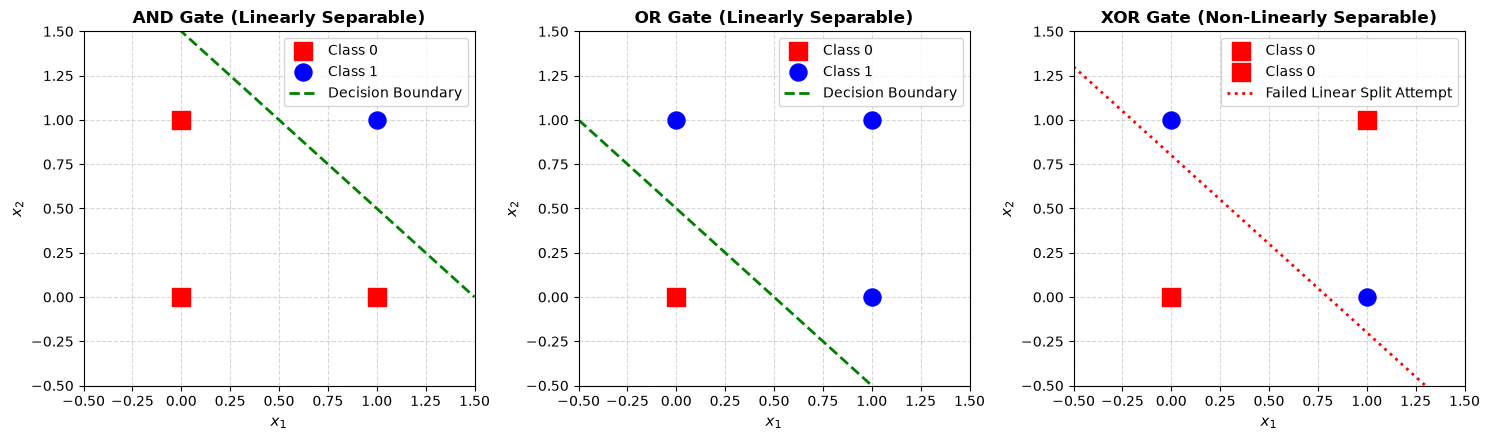

In [5]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

gate_titles = ["AND Gate (Linearly Separable)", "OR Gate (Linearly Separable)", "XOR Gate (Non-Linearly Separable)"]
gate_outputs = [np.array([0, 0, 0, 1]), np.array([0, 1, 1, 1]), np.array([0, 1, 1, 0])]


for idx, ax in enumerate(axes):
    y_targets = gate_outputs[idx]
    
    # Scatter points
    for i in range(len(X_gate)):
        color = 'blue' if y_targets[i] == 1 else 'red'
        marker = 'o' if y_targets[i] == 1 else 's'
        ax.scatter(X_gate[i, 0], X_gate[i, 1], color=color, marker=marker, s=150, zorder=5, label=f'Class {y_targets[i]}' if i in [0, 3] else "")
    
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel("$x_1$", fontsize=11)
    ax.set_ylabel("$x_2$", fontsize=11)
    ax.set_title(gate_titles[idx], fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    

x_vals = np.linspace(-0.5, 1.5, 100)

axes[0].plot(x_vals, 1.5 - x_vals, 'g--', linewidth=2, label="Decision Boundary")

axes[1].plot(x_vals, 0.5 - x_vals, 'g--', linewidth=2, label="Decision Boundary")

axes[2].plot(x_vals, 0.8 - x_vals, 'r:', linewidth=2, label="Failed Linear Split Attempt")

for ax in axes:
    ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig("perceptron_gate_decision_boundaries.png", dpi=150)
plt.show()

## 7. Real-World Machine Learning Application: Synthetic Classification

Let's test our manual Perceptron on a synthetic binary classification dataset generated with `scikit-learn`.

[+] Converged successfully at Epoch 2!
Training Complete! Test Accuracy: 100.00%


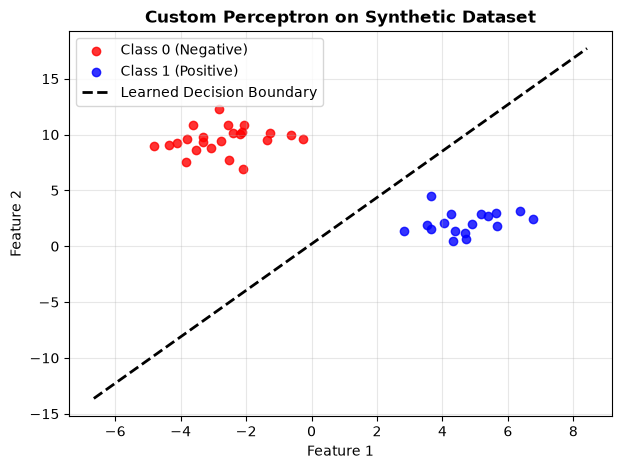

In [6]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Generate linearly separable 2D synthetic dataset
X_synth, y_synth = make_blobs(n_samples=200, centers=2, cluster_std=1.2, random_state=42)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_synth, y_synth, test_size=0.2, random_state=42)

# Instantiate and train Perceptron
model = Perceptron(learning_rate=0.01, epochs=50)
model.fit(X_train, y_train)

# Predict and Evaluate
y_pred_test = model.predict(X_test)
acc = accuracy_score(y_test, y_pred_test)
print(f"Training Complete! Test Accuracy: {acc * 100:.2f}%")

# Plot synthetic dataset decision boundary
plt.figure(figsize=(7, 5))
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], color='red', label='Class 0 (Negative)', alpha=0.8)
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], color='blue', label='Class 1 (Positive)', alpha=0.8)

# Calculate boundary line: w1*x1 + w2*x2 + b = 0 => x2 = (-w1*x1 - b) / w2
x1_range = np.linspace(X_synth[:, 0].min() - 1, X_synth[:, 0].max() + 1, 100)
x2_boundary = (-model.weights[0] * x1_range - model.bias) / model.weights[1]
plt.plot(x1_range, x2_boundary, 'k--', linewidth=2, label='Learned Decision Boundary')

plt.title("Custom Perceptron on Synthetic Dataset", fontsize=12, fontweight='bold')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("perceptron_synthetic_dataset.png", dpi=150)
plt.show()